<a href="https://colab.research.google.com/github/amandalaraujo/analise-dados-sihsus-diabetes/blob/main/TRAB_IA_%7C_DADOS_PI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predição de Óbito em Internações por Diabetes (SIHSUS)
> Este projeto foi desenvolvido como estudo prático no âmbito acadêmico para aplicar técnicas de Análise de Dados, Preparação de Dados e Machine Learning (Regressão Logística) em um cenário de dados reais do ecossistema público de saúde do Brasil (SIHSUS).

**Trabalho de Dados e IA**

Nosso projeto analisa dados públicos do **SIHSUS** (Sistema de Informações Hospitalares do SUS) referentes a internações por **diabetes mellitus (CID-10: E10 a E14)**, com o objetivo de identificar padrões clínicos associados a óbito e complicações graves durante a internação, e treinar um modelo de Regressão Logística capaz de estimar o risco de óbito para cada paciente.

## 1. Definição do Problema

**Problema:** prever o risco de desfecho grave (óbito) durante a internação hospitalar de pacientes diabéticos.

**Pergunta que o modelo responde:** dado o perfil de um paciente internado por diabetes (idade, sexo, raça/cor, tempo de permanência, se precisou de UTI, região), qual a probabilidade de óbito ou complicação grave durante a internação?

**Variável alvo:** `MORTE` — variável binária (0 = Sobreviveu, 1 = Óbito).

**Por que isso importa:** identificar precocemente pacientes com maior risco permite priorizar recursos hospitalares (leitos de UTI, monitoramento mais próximo) e apoiar decisões clínicas baseadas em dados.

## 2. Configuração do Ambiente


Importação das bibliotecas utilizadas em todo o notebook e montagem do Google Drive, onde estão os arquivos brutos do SIHSUS.

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Montar o Google Drive:
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Coleta e Preparação dos Dados (ETL)

Os arquivos do SIHSUS são baixados em formato CSV, um por competência (mês/ano), e podem variar em separador (`,` ou `;`) e codificação (`UTF-8` ou `ISO-8859-1`). Por isso, a leitura é feita com uma função de fallback que testa essas combinações automaticamente.

**Regras de negócio aplicadas nesta etapa:**

- **Filtro da população de estudo:** mantemos apenas internações cujo diagnóstico principal (`DIAG_PRINC`) começa com E10, E11, E12, E13 ou E14 — os códigos CID-10 de diabetes mellitus.
- **Classificação da complicação grave (`TIPO_COMPLICACAO`):** cada internação é rotulada em uma das categorias abaixo, seguindo uma ordem de prioridade clínica (a mais grave prevalece quando há mais de uma):
  1. **Amputação** — identificada pelo código do procedimento realizado (ex.: amputação de membros, pé/tarso, dedo), excluindo códigos de revisão de coto.
  2. **Coma Diabético** — diagnóstico com subcategoria `.0` dos códigos E10–E14.
  3. **Cetoacidose** — diagnóstico com subcategoria `.1` dos códigos E10–E14.
  4. **Sem complicação grave registrada** — quando nenhuma das condições acima é observada.

O resultado final é um único DataFrame `df`, consolidando todos os arquivos mensais já filtrados e rotulados.

In [ ]:
# ==============================================================================
# 1. MAPEAMENTO DE REGRAS DE NEGÓCIO (SUS / DIABETES)
# ==============================================================================
CIDS_DIABETES = ['E10', 'E11', 'E12', 'E13', 'E14']
CIDS_COMA = ['E100', 'E110', 'E120', 'E130', 'E140', 'E10.0', 'E11.0', 'E12.0', 'E13.0', 'E14.0']
CIDS_CETOACIDOSE = ['E101', 'E111', 'E121', 'E131', 'E141', 'E10.1', 'E11.1', 'E12.1', 'E13.1', 'E14.1']

PROC_AMPUTACAO = [
    '0408020024',  # Amputação/desarticulação de membros superiores
    '0408050012',  # Amputação/desarticulação de membros inferiores
    '0408050020',  # Amputação/desarticulação de pé e tarso
    '0408060042',  # Amputação/desarticulação de dedo
]

PROC_REVISAO_COTO = [
    '0408050330',
    '0408060425',
]

def identificar_complicacao(row, col_diag, col_proc, col_nome_proc=None):
    """Classifica a complicação grave por ordem de prioridade (Amputação > Coma > Cetoacidose)."""
    diag = str(row.get(col_diag, '')).strip().upper().replace('.', '') if col_diag else ''
    proc = str(row.get(col_proc, '')).strip() if col_proc else ''
    nome_proc = str(row.get(col_nome_proc, '')).strip().upper() if col_nome_proc else ''

    is_amputacao = (
        proc in PROC_AMPUTACAO
        or ('AMPUTA' in nome_proc and proc not in PROC_REVISAO_COTO and 'REVISAO' not in nome_proc)
    )
    is_coma = any(diag.startswith(c.replace('.', '')) for c in CIDS_COMA)
    is_ceto = any(diag.startswith(c.replace('.', '')) for c in CIDS_CETOACIDOSE)

    if is_amputacao:
        return 'Amputação'
    elif is_coma:
        return 'Coma Diabético'
    elif is_ceto:
        return 'Cetoacidose'
    return 'Sem complicação grave registrada'

def ler_csv_sihsus(file_path):
    """Leitura com fallback de delimitador e encoding para acomodar variabilidades do SIHSUS."""
    tentativas = [
        {'sep': ',', 'encoding': 'utf-8-sig'},
        {'sep': ',', 'encoding': 'iso-8859-1'},
        {'sep': ';', 'encoding': 'utf-8-sig'},
        {'sep': ';', 'encoding': 'iso-8859-1'},
    ]

    colunas_diag_candidatas = ['DIAG_PRINC', 'DIAGPRINC', 'DIAG_PRI', 'CID']

    for tentativa in tentativas:
        try:
            df = pd.read_csv(file_path, low_memory=False, **tentativa)
        except Exception:
            continue

        df.columns = [str(c).upper().strip() for c in df.columns]
        df = df.loc[:, ~df.columns.duplicated()].copy()

        if len(df.columns) > 1 and any(c in df.columns for c in colunas_diag_candidatas):
            return df

    return None

# ==============================================================================
# 2. CARREGAMENTO DOS DADOS DO DRIVE NO COLAB
# ==============================================================================
pasta = '/content/drive/MyDrive/PROJETO_DIABETES'

# Busca arquivos .csv e .CSV (para evitar problemas no Linux)
arquivos = sorted(glob.glob(os.path.join(pasta, '*.csv')) + glob.glob(os.path.join(pasta, '*.CSV')))
print(f'Total de {len(arquivos)} arquivos encontrados na pasta.')

if len(arquivos) == 0:
    print(f"\n❌ ERRO: Nenhum arquivo CSV foi localizado na pasta: {pasta}")
    print("Verifique se o caminho no seu Google Drive está correto (ex: 'PROJETO_DIABETES' ou 'PROJETO_DIABETES/dados_brutos').")
else:
    partes = []

    for arq in arquivos:
        nome_arq = os.path.basename(arq)
        print(f"Processando: {nome_arq}...")

        # Utiliza a função inteligente do seu ETL
        df_temp = ler_csv_sihsus(arq)

        if df_temp is None:
            print(f"   └─ ❌ Não foi possível ler {nome_arq} com nenhuma combinação conhecida de sep/encoding.")
            continue

        total_bruto = len(df_temp)

        # Identifica a coluna de Diagnóstico
        col_diag = None
        for col_cand in ['DIAG_PRINC', 'DIAGPRINC', 'DIAG_PRI', 'CID']:
            if col_cand in df_temp.columns:
                col_diag = col_cand
                break

        # Identifica a coluna de Procedimento
        col_proc = None
        for col_cand in ['PROC_REA', 'PROC_SOL', 'PA_PROCID']:
            if col_cand in df_temp.columns:
                col_proc = col_cand
                break

        # Trata a formatação da coluna de procedimento (zero à esquerda)
        if col_proc:
            df_temp[col_proc] = (
                df_temp[col_proc]
                .astype(str)
                .str.replace(r'\.0$', '', regex=True)
                .str.zfill(10)
            )

        # Filtra apenas registros de Diabetes (E10 a E14)
        if col_diag:
            mascara_diabetes = df_temp[col_diag].astype(str).str.strip().str.upper().apply(
                lambda cid: any(cid.startswith(c) for c in CIDS_DIABETES)
            )
            df_filtrado = df_temp[mascara_diabetes].copy()
            total_filtrado = len(df_filtrado)

            if total_filtrado > 0:
                # Aplica a rotulagem de complicações
                df_filtrado['TIPO_COMPLICACAO'] = df_filtrado.apply(
                    lambda row: identificar_complicacao(
                        row, col_diag, col_proc, col_nome_proc='DEF_PROCEDIMENTO_REALIZADO'
                    ),
                    axis=1
                )
                df_filtrado['arquivo_origem'] = nome_arq
                partes.append(df_filtrado)
                print(f"   └─ Total lido: {total_bruto:,} | Casos de Diabetes: {total_filtrado:,}")
            else:
                print(f"   └─ Nenhum caso de diabetes encontrado em {nome_arq}")
        else:
            print(f"   └─ Coluna de Diagnóstico não encontrada em {nome_arq}")

    # Consolida os DataFrames em uma única estrutura
    if partes:
        df = pd.concat(partes, ignore_index=True)
        print(f"\n✅ ETL do Colab concluído com sucesso!")
        print(f"Dimensão final do DataFrame: {df.shape[0]:,} linhas e {df.shape[1]} colunas.")
    else:
        print("\n⚠️ Nenhum registro correspondente a Diabetes foi importado.")

Total de 12 arquivos encontrados na pasta.
Processando: ETLSIH.ST_SP_2025_10_t.csv...
   └─ Total lido: 256,622 | Casos de Diabetes: 2,532
Processando: ETLSIH.ST_SP_2025_11_t.csv...
   └─ Total lido: 239,614 | Casos de Diabetes: 2,321
Processando: ETLSIH.ST_SP_2025_12_t.csv...
   └─ Total lido: 230,730 | Casos de Diabetes: 2,320
Processando: ETLSIH.ST_SP_2025_1_t.csv...
   └─ Total lido: 238,144 | Casos de Diabetes: 2,194
Processando: ETLSIH.ST_SP_2025_2_t.csv...
   └─ Total lido: 231,291 | Casos de Diabetes: 1,901
Processando: ETLSIH.ST_SP_2025_3_t.csv...
   └─ Total lido: 245,839 | Casos de Diabetes: 2,025
Processando: ETLSIH.ST_SP_2025_4_t.csv...
   └─ Total lido: 244,996 | Casos de Diabetes: 1,931
Processando: ETLSIH.ST_SP_2025_5_t.csv...
   └─ Total lido: 259,070 | Casos de Diabetes: 2,005
Processando: ETLSIH.ST_SP_2025_6_t.csv...
   └─ Total lido: 245,373 | Casos de Diabetes: 2,010
Processando: ETLSIH.ST_SP_2025_7_t.csv...
   └─ Total lido: 254,708 | Casos de Diabetes: 2,375
Proc

## 4. Análise Exploratória de Dados (EDA)

Antes de treinar qualquer modelo, focamos em entender o comportamento dos dados: o quão desbalanceada é a variável alvo, como o tempo de internação se relaciona com o óbito, quais complicações são mais letais, e a qualidade estrutural das variáveis (dados faltantes).

### 4.1 Distribuição da variável alvo (óbito)

**O que este gráfico mostra:** a proporção de pacientes que sobreviveram versus os que foram a óbito no conjunto de dados completo.

In [ ]:
# ==============================================================================
# DISTRIBUIÇÃO DA VARIÁVEL ALVO (OBITO)
# ==============================================================================

plt.figure(figsize=(6,4))
# Salva o gráfico na variável 'ax' para podermos manipular os rótulos depois
ax = df['MORTE'].value_counts(normalize=True).rename({0:'Sobreviveu', 1:'Óbito'}).plot(kind='bar', color=['#4C72B0', '#C44E52'])

plt.title('Proporção de Óbitos no Dataset (Desbalanceamento)')
plt.ylabel('Proporção')
plt.xticks(rotation=0)

# Adiciona as porcentagens no topo de cada barra
for p in ax.patches:
    altura = p.get_height()
    # Formata como porcentagem com 1 casa decimal
    ax.annotate(f'{altura:.1%}',
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, 1.1)
plt.show()

> **Resultado:** `value_counts(normalize=True)` retorna a proporção (fração decimal de 0 a 1) em vez da contagem absoluta. O resultado mostra que **96,3%** dos pacientes sobreviveram e apenas **3,7%** foram a óbito. Isso confirma um **forte desbalanceamento de classes** — um desafio central deste problema, já que um modelo "ingênuo" que sempre prevê "sobreviveu" já acertaria 96% das vezes, mas seria clinicamente inútil (nunca identificaria um óbito). Esse desbalanceamento justifica o uso do parâmetro `class_weight='balanced'` no modelo, tratado na Seção 5.

In [ ]:
# ==============================================================================
# HISTOGRAMA DE DIAS_PERM POR OBITO
# ==============================================================================

# Agrupa os dias de internação em faixas (bins) e mostra a porcentagem real
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# O parâmetro bins=range(0, 45, 5) cria colunas de 5 em 5 dias (0-5, 5-10, etc.)
# stat='percent' muda o eixo Y para porcentagem (0 a 100)
# common_norm=False garante que a porcentagem seja calculada isoladamente para quem sobreviveu e quem foi a óbito
sns.histplot(data=df, x='DIAS_PERM', hue='MORTE',
             bins=range(0, 45, 5),
             multiple='dodge',
             stat='percent',
             common_norm=False,
             palette=['#4C72B0', '#C44E52'],
             alpha=0.8)

plt.xlim(0, 40)

# Ajustes de texto
plt.title('Tempo de Permanência Agrupado (Faixas de 5 dias)', fontsize=12)
plt.xlabel('Dias de Permanência (DIAS_PERM)', fontsize=10)
plt.ylabel('Porcentagem de Pacientes (%)', fontsize=10)

# Customizando a legenda
plt.legend(title='Desfecho', labels=['Óbito', 'Sobreviveu'])

plt.show()

> **Resultado:** `common_norm=False` faz com que a porcentagem seja calculada separadamente dentro de cada grupo (óbito e sobreviveu), permitindo comparar as formas das duas distribuições mesmo com tamanhos de amostra muito diferentes.
O gráfico mostra que a maior parte dos pacientes que **sobreviveram** tem internações curtas — concentração forte nas faixas de 0 a 10 dias. Já entre os pacientes que foram a **óbito**, embora a maioria também esteja nas faixas iniciais, a distribuição é mais "espalhada" para a direita, com uma proporção maior de casos em faixas mais longas (15–35 dias) comparado ao grupo de sobreviventes. Isso sugere que internações prolongadas estão associadas a maior gravidade clínica e, consequentemente, a maior risco de óbito — o que justifica o uso de `DIAS_PERM` como variável preditiva no modelo.

### 4.3 Taxa de óbito por tipo de complicação

**O que este gráfico mostra:** para cada tipo de complicação grave identificada na etapa de ETL (Amputação, Coma Diabético, Cetoacidose ou Sem complicação grave registrada), a proporção de óbitos **dentro daquele grupo** — ou seja, entre os pacientes que tiveram aquela complicação, quantos morreram. A linha pontilhada marca a taxa média geral de óbitos do dataset, servindo como referência (baseline) para saber se cada complicação está acima ou abaixo da média.

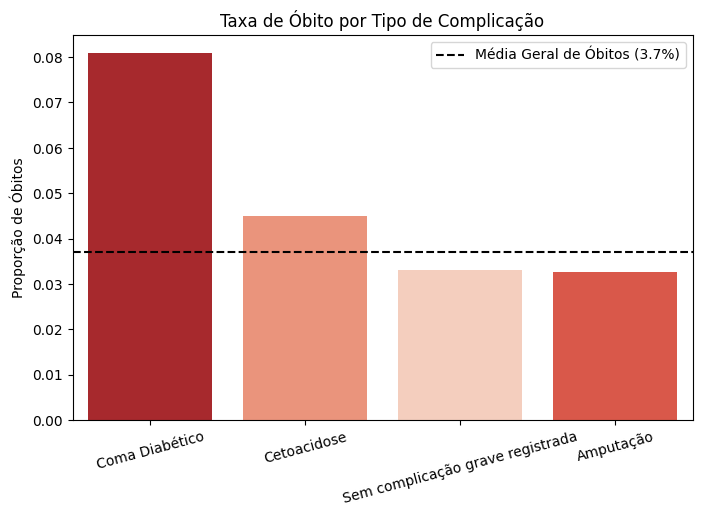

In [ ]:
# ==============================================================================
# TAXA DE OBITO POR TIPO DE COMPLICAÇÃO
# ==============================================================================

plt.figure(figsize=(8,5))

# Calcula a ordem das barras primeiro
ordem = df.groupby('TIPO_COMPLICACAO')['MORTE'].mean().sort_values(ascending=False).index

# hue='TIPO_COMPLICACAO' e legend=False também aplicados aqui para evitar o aviso
sns.barplot(data=df, x='TIPO_COMPLICACAO', y='MORTE', hue='TIPO_COMPLICACAO',
            palette='Reds', errorbar=None, order=ordem, legend=False)

plt.title('Taxa de Óbito por Tipo de Complicação')
plt.ylabel('Proporção de Óbitos')
plt.xlabel('') # Limpa o título do eixo X para ficar mais limpo
plt.xticks(rotation=15)

# Adicionando a linha de base
media_geral = df['MORTE'].mean()
plt.axhline(y=media_geral, color='black', linestyle='--', linewidth=1.5,
            label=f'Média Geral de Óbitos ({media_geral:.1%})')
plt.legend() # Mostra a legenda com a média geral

plt.show()

> **Resultado:** o **Coma Diabético** apresenta a maior letalidade — cerca de **8%** dos pacientes com esse quadro foram a óbito, mais que o dobro da média geral (3,7%). Em seguida vem a **Cetoacidose** (~4,5%), também acima da média. Já **Amputação** e **Sem complicação grave registrada** ficam abaixo da média geral. Esse resultado é **clinicamente coerente**: coma diabético é a complicação aguda mais grave dentre as avaliadas, então é esperado que tenha a maior letalidade, seguida da cetoacidose. Isso reforça `TIPO_COMPLICACAO` (transformada em `complicacao_grave` no modelo) como uma variável preditiva relevante.

### 4.4 Qualidade dos dados — valores faltantes

**O que esta tabela mostra:** a quantidade e o percentual de valores faltantes (nulos) nas colunas-chave que serão utilizadas no modelo (`IDADE`, `DIAS_PERM`, `SEXO`, `UTI_MES_TO`, `MORTE`). Adicionamos essa verificação antes de treinar qualquer modelo, pois dados faltantes não tratados podem gerar erros ou distorcer os resultados.

In [ ]:
# ==============================================================================
# MOSTRA VALORES FALTANTES NAS COUNAS-CHAVE
# ==============================================================================

# Mostra a qualidade estrutural dos dados em formato de tabela
cols_chave = ['IDADE','DIAS_PERM','SEXO','UTI_MES_TO','MORTE']

# Cria um DataFrame de resumo
resumo_nulos = pd.DataFrame({
    'Valores Faltantes': df[cols_chave].isnull().sum(),
    '% de Faltantes': df[cols_chave].isnull().sum() / len(df) * 100,
})

print("Resumo de Qualidade de Dados (Nulos):")
display(resumo_nulos)

> **Resultado:** todas as colunas-chave (`IDADE`, `DIAS_PERM`, `SEXO`, `UTI_MES_TO`, `MORTE`) apresentam **0 valores faltantes (0,0%)**. Isso indica boa qualidade estrutural dos dados do SIHSUS para essas variáveis e significa que não será necessário aplicar nenhuma técnica de imputação antes de treinar o modelo.

## 5. Modelo Preditivo — Regressão Logística

**Por que Regressão Logística:** é o algoritmo supervisionado de classificação binária mais simples e interpretável para prever o risco de óbito hospitalar com base nas variáveis do paciente, servindo como ponto de partida (**baseline**) para o problema.

**Variáveis utilizadas (features):**
- `IDADE` — idade do paciente
- `DIAS_PERM` — tempo de permanência na internação
- `usou_uti_bin` — indicador binário de uso de UTI
- `complicacao_grave` — indicador binário de complicação grave (derivado de `TIPO_COMPLICACAO`)

**Tratamentos aplicados:**
- `stratify=y` na divisão treino/teste, para manter a mesma proporção de óbitos em ambos os conjuntos.
- Normalização das variáveis com `StandardScaler`, já que a Regressão Logística converge melhor quando as variáveis estão na mesma escala.
- `class_weight='balanced'`, que compensa o forte desbalanceamento identificado na Seção 4.1 (apenas 3,7% de óbitos), penalizando mais os erros na classe minoritária durante o treinamento.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Features mais ricas (incluindo UTI e complicação, que você já criou)
df_model = df.copy()
df_model['usou_uti_bin'] = df_model['UTI_MES_TO'].astype(int) # Corrected column name and conversion
df_model['complicacao_grave'] = (df_model['TIPO_COMPLICACAO'] != 'Sem complicação grave registrada').astype(int)

features = ['IDADE', 'DIAS_PERM', 'usou_uti_bin', 'complicacao_grave']
# se quiser, adicione SEXO, CBOR (raça/cor) e IBGE região como dummies:
# df_model = pd.get_dummies(df_model, columns=['SEXO', 'CBOR'], drop_first=True)

target = 'MORTE' # Corrected target variable name
df_baseline = df_model[features + [target]].dropna()

X = df_baseline[features]
y = df_baseline[target]

# 2. IMPORTANTE: stratify=y para manter a proporção de óbitos em treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Normalizar (ajuda a regressão logística convergir melhor com variáveis em escalas diferentes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. class_weight='balanced' é a mudança que mais vai impactar seu resultado
baseline_model = LogisticRegression(class_weight='balanced', max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
y_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("=== MÉTRICAS DO MODELO BASELINE ===")
print(classification_report(y_test, y_pred, target_names=['Sobreviveu', 'Óbito']))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

> **Resultado do modelo baseline:**

  - **Recall (Óbito) = 0,71** → o modelo identifica corretamente 138 dos 195 óbitos reais do conjunto de teste (71%). Essa é a métrica mais importante clinicamente: queremos captar quem está em risco.
  - **Precision (Óbito) = 0,08** → apenas 138 dos 1.677 pacientes classificados como "risco de óbito" realmente morreram — ou seja, muitos falsos alarmes (1.539 falsos positivos).
  - **Trade-off esperado:** o modelo passou a detectar bem mais óbitos, mas ao custo de menos precisão (aponta risco também em pacientes que sobreviveram). A acurácia caiu de ~0,96 (se o modelo apenas "chutasse" a classe majoritária) para 0,70 — mas essa queda é aceitável e até esperada, pois a acurácia é uma métrica pouco informativa em problemas tão desbalanceados.
  - **AUC-ROC = 0,7812** → esta é a métrica mais honesta para reportar a qualidade geral do modelo baseline, pois mede a capacidade de discriminação do modelo (a probabilidade de ranquear corretamente um óbito acima de um sobrevivente) independentemente do limiar de decisão escolhido. Um valor de 0,78 é um resultado razoável para um baseline simples com apenas 4 variáveis (bem acima de 0,5, que representaria um "chute aleatório").

## 6. Sensibilidade e Especificidade

- **Sensibilidade** (também chamada de Recall da classe positiva): entre todos os pacientes que realmente foram a óbito, qual proporção o modelo conseguiu identificar corretamente. Alta sensibilidade é essencial em contexto de saúde, pois significa "não deixar passar" casos graves.
- **Especificidade** (Recall da classe negativa): entre todos os pacientes que realmente sobreviveram, qual proporção o modelo classificou corretamente como de baixo risco. Alta especificidade significa poucos falsos alarmes.

Ambas são calculadas diretamente a partir da matriz de confusão (`TN`, `FP`, `FN`, `TP`).

In [ ]:
# Sensibilidade e Especificidade (a partir da matriz de confusão)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensibilidade = tp / (tp + fn)  # Recall da classe Óbito (verdadeiro positivo)
especificidade = tn / (tn + fp)  # Recall da classe Sobreviveu (verdadeiro negativo)

print("=== SENSIBILIDADE E ESPECIFICIDADE ===")
print(f"Sensibilidade (Recall - Óbito):        {sensibilidade:.4f} ({sensibilidade:.1%})")
print(f"Especificidade (Recall - Sobreviveu):  {especificidade:.4f} ({especificidade:.1%})")
print(f"\nVerdadeiros Negativos (TN): {tn}")
print(f"Falsos Positivos (FP):      {fp}")
print(f"Falsos Negativos (FN):      {fn}")
print(f"Verdadeiros Positivos (TP): {tp}")

> **Resultado:**

  - **Sensibilidade = 70,8%** — o modelo captura corretamente cerca de 7 em cada 10 óbitos reais.
  - **Especificidade = 69,7%** — o modelo classifica corretamente cerca de 7 em cada 10 pacientes que sobreviveram.

  O equilíbrio entre essas duas métricas (ambas em torno de 70%) mostra que o modelo, com `class_weight='balanced'` e o limiar padrão de 0,5, não está "favorecendo" nenhuma das duas classes de forma desproporcional — ele sacrifica uma boa parte de precisão para conseguir captar a maioria dos óbitos, o que é uma escolha adequada em um contexto clínico onde deixar de identificar um óbito (falso negativo) é geralmente mais custoso do que gerar um alarme falso.

## 7. Curva ROC e AUROC

A **Curva ROC** (Receiver Operating Characteristic) plota a Taxa de Verdadeiros Positivos (Sensibilidade) contra a Taxa de Falsos Positivos (1 − Especificidade) para **todos os limiares de decisão possíveis** — não apenas para o limiar de 0,5 usado no `predict()` padrão. A área sob essa curva (**AUC**, já reportada na Seção 5) resume, em um único número, a capacidade do modelo de separar as duas classes.

In [ ]:
# Curva ROC (AUROC)
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#C44E52', lw=2.5, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Classificador aleatório (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=10)
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=10)
plt.title('Curva ROC - Modelo de Regressão Logística', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

> **Resultado:** a curva do modelo (em vermelho) fica claramente acima da diagonal cinza (que representa um classificador aleatório, AUC = 0,5), confirmando visualmente o **AUC-ROC de 0,7812** já calculado. Isso indica que o modelo tem uma capacidade de discriminação **razoável a boa**: se pegarmos aleatoriamente um paciente que foi a óbito e outro que sobreviveu, o modelo atribui uma probabilidade de risco maior ao paciente que morreu em aproximadamente 78% das vezes.
A curva também deixa visível o trade-off entre sensibilidade e especificidade: para ganhar mais sensibilidade (subir no eixo Y), é necessário aceitar mais falsos positivos (andar para a direita no eixo X). Esse trade-off é explorado com mais detalhe na próxima seção, ao testarmos diferentes limiares de decisão.


## 8. Ajuste do Limiar de Decisão (Threshold)

Por padrão, o método `.predict()` do scikit-learn classifica como "Óbito" todo paciente com probabilidade prevista ≥ **0,5**. Porém, em problemas com forte desbalanceamento de classes (como este, com apenas 3,7% de óbitos), esse limiar padrão raramente é o mais adequado — ele foi pensado para problemas balanceados.

Nesta seção, testamos diferentes limiares (de 0,10 a 0,95) e observamos como a sensibilidade e a especificidade variam em cada um, permitindo escolher o ponto de equilíbrio mais adequado ao objetivo do problema.

In [ ]:
# Ajuste de threshold (trade-off sensibilidade x especificidade)
import numpy as np

thresholds_teste = np.arange(0.1, 1.0, 0.05)
resultados = []

for t in thresholds_teste:
    y_pred_t = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

    sens_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    esp_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0

    resultados.append({
        'threshold': round(t, 2),
        'sensibilidade': round(sens_t, 4),
        'especificidade': round(esp_t, 4),
        'soma_sens_esp': round(sens_t + esp_t, 4)  # útil pra achar o ponto de equilíbrio
    })

df_thresholds = pd.DataFrame(resultados)
display(df_thresholds)

# Threshold que maximiza sensibilidade + especificidade (ponto de equilíbrio ótimo)
melhor_threshold = df_thresholds.loc[df_thresholds['soma_sens_esp'].idxmax(), 'threshold']
print(f"\nThreshold sugerido (melhor equilíbrio sens/esp): {melhor_threshold}")

# Visualizando o trade-off
plt.figure(figsize=(8, 5))
plt.plot(df_thresholds['threshold'], df_thresholds['sensibilidade'], marker='o', label='Sensibilidade', color='#C44E52')
plt.plot(df_thresholds['threshold'], df_thresholds['especificidade'], marker='o', label='Especificidade', color='#4C72B0')
plt.axvline(x=melhor_threshold, color='black', linestyle='--', alpha=0.6, label=f'Threshold ótimo ({melhor_threshold})')
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.6, label='Threshold padrão (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Taxa')
plt.title('Trade-off entre Sensibilidade e Especificidade por Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

> **Resultado:** a tabela e o gráfico mostram claramente o trade-off inverso entre as duas métricas — conforme o limiar aumenta, a sensibilidade cai e a especificidade sobe. No limiar mais baixo (0,10), a sensibilidade é de 100% (o modelo identifica todos os óbitos), mas a especificidade despenca para 7,3% (quase todo mundo é classificado como risco). No limiar mais alto (0,95), ocorre o oposto.
O ponto de equilíbrio (**threshold ótimo = 0,50**, encontrado maximizando a soma sensibilidade + especificidade) coincide, neste caso, com o limiar padrão do scikit-learn — o que confirma que a combinação `class_weight='balanced'` + limiar de 0,5 já estava produzindo um ponto de operação equilibrado para este modelo, sem necessidade de recalibração manual.

> **Conclusão prática:** dependendo do objetivo do trabalho, a equipe pode justificar a escolha de um limiar diferente de 0,5. Por exemplo, se o objetivo prioritário fosse **nunca deixar passar um óbito** (mesmo ao custo de mais falsos alarmes), um limiar mais baixo (ex.: 0,30–0,35) poderia ser adotado — trade-off relevante de se discutir em qualquer aplicação de IA em saúde pública.

## 9. Conclusão

O modelo de Regressão Logística construído a partir dos dados do SIHSUS para pacientes internados por diabetes apresentou um desempenho consistente como **baseline**:

- **AUC-ROC de 0,78**, indicando boa capacidade de discriminação entre pacientes de alto e baixo risco de óbito.
- **Sensibilidade de ~71%** e **Especificidade de ~70%**, um equilíbrio adequado para um problema de saúde fortemente desbalanceado (apenas 3,7% de óbitos na base).
- A análise de limiares de decisão confirmou que o ponto de corte padrão (0,5) já representa um bom equilíbrio entre "captar óbitos" e "evitar falsos alarmes" para este modelo.

**Principais achados clínicos da EDA:**
- Internações mais longas estão associadas a maior risco de óbito.
- Coma diabético é a complicação com maior letalidade (~ 8%), seguida de cetoacidose (~4,5%), ambas acima da média geral de óbitos (3,7%).

**Possíveis próximos passos:** incluir variáveis adicionais (sexo, raça/cor, região), testar modelos mais complexos (Random Forest, XGBoost) e comparar seu desempenho (AUC, sensibilidade, especificidade) com o baseline aqui estabelecido.